In [1]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt

In [2]:
data_path = '40Sen_30Sec_stomping_30sec_quiet.csv' 
data = pd.read_csv(data_path)
distances =  pd.read_csv('dist.csv')
print("Data shape:", data.shape)
print("First few rows:")
print(data.head())
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Data shape: (59999, 40)
First few rows:
    -0.0301  -0.00059605  -0.0044703  -0.0056624  -0.0083447  -0.0011921  \
0 -0.046492     0.003278   -0.005960   -0.009537   -0.008047    0.002980   
1 -0.059307     0.000000    0.001192   -0.008047   -0.006259   -0.000596   
2 -0.056624    -0.001192    0.008941    0.000596   -0.000596   -0.003874   
3 -0.039339    -0.000298    0.012815   -0.004470    0.001490   -0.001788   
4 -0.021160    -0.001192    0.013411   -0.012517   -0.001192    0.002384   

   -0.011623  -0.00089407  -0.00059605.1  -0.0098348  ...  0.0074506  \
0  -0.018775    -0.000894      -0.004470   -0.008345  ...   0.037849   
1  -0.014007     0.002682      -0.004470   -0.005960  ...   0.032187   
2  -0.005662     0.004172      -0.005662   -0.002682  ...   0.006259   
3   0.005662     0.005066      -0.008941    0.003278  ...  -0.032783   
4   0.014007     0.004172      -0.006556    0.006855  ...  -0.054836   

   0.010729  0.00029802  -0.0074506  -0.022352  0.068545  -0.010133  \

```markdown
### Data Preparation

In this notebook, we are working with audio data to distinguish between quiet and loud segments. The data is loaded from a CSV file and contains multiple columns representing different sensors.

1. **Loading Data**: We start by loading the data from the CSV file `40Sen_30Sec_stomping_30sec_quiet.csv`.
2. **Data Segmentation**: The data is segmented into quiet and noisy samples. The last 28 seconds of the data are considered quiet, and the rest is considered noisy.
3. **Saving Segments**: The segmented data is saved into separate CSV files for further analysis.

The variables used in this process include:
- `data`: The entire dataset loaded from the CSV file.
- `quiet_samples`: The last 28 seconds of the data, representing quiet segments.
- `noisy_samples`: The remaining data, representing noisy segments.

Next, we will focus on learning the characteristics of the quiet segments and later remove these characteristics from the loud segments.
```

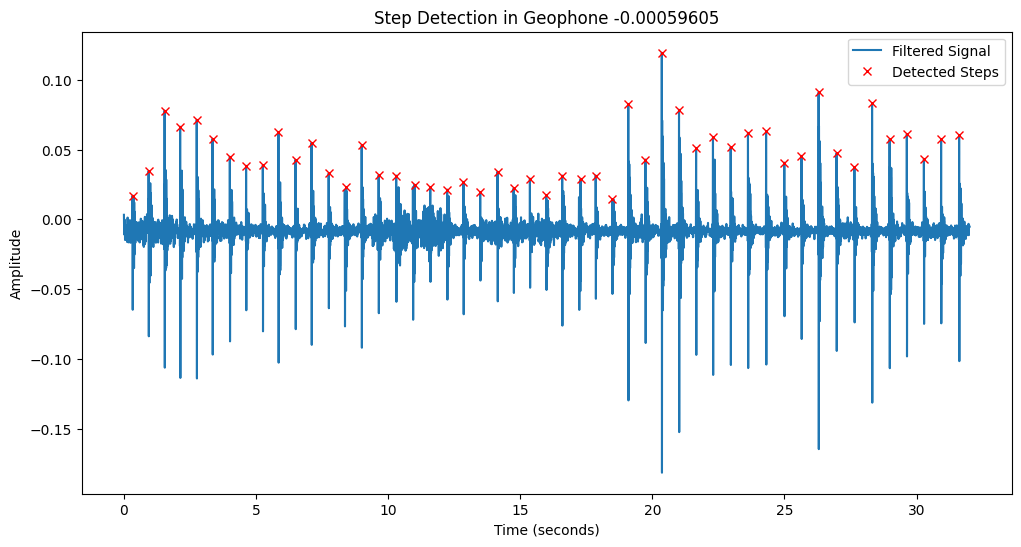

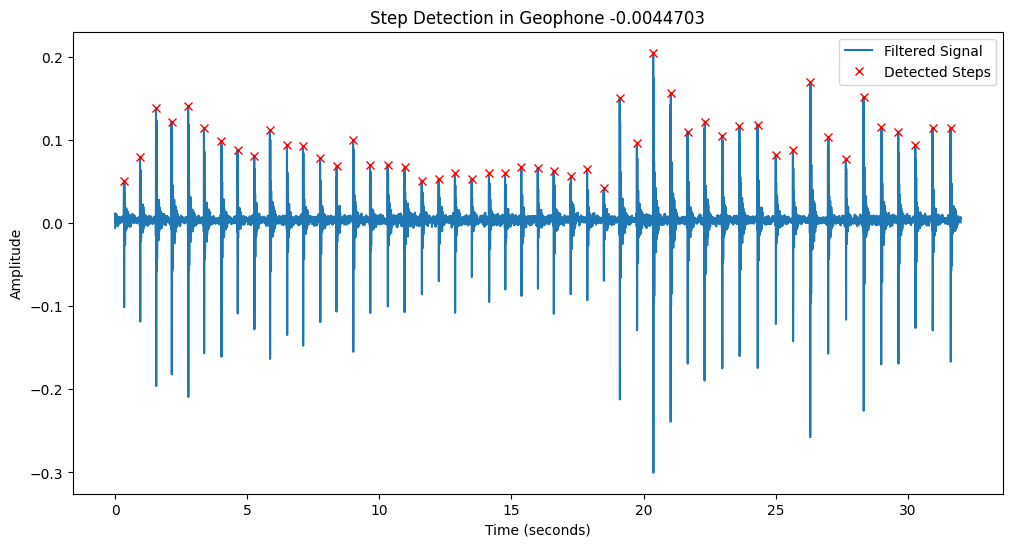

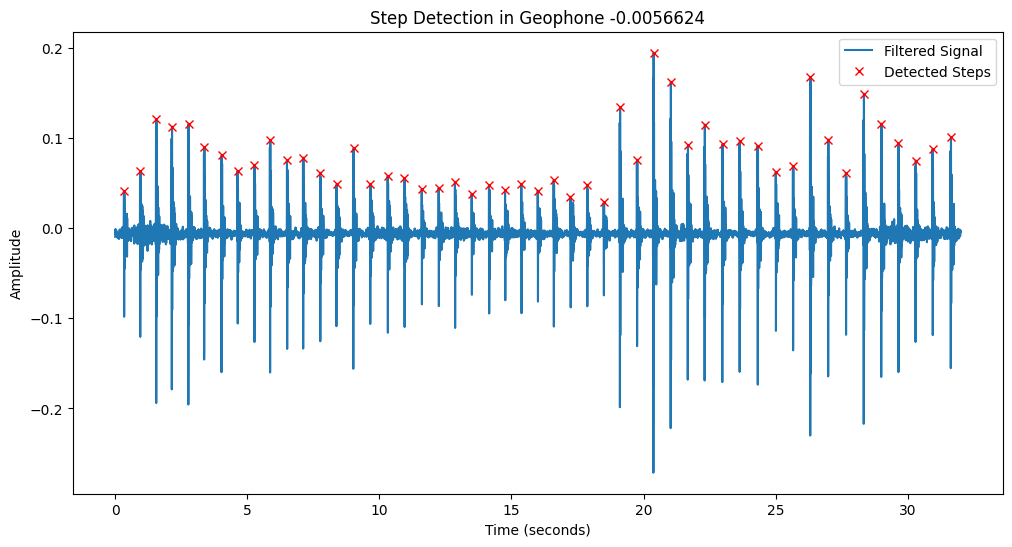

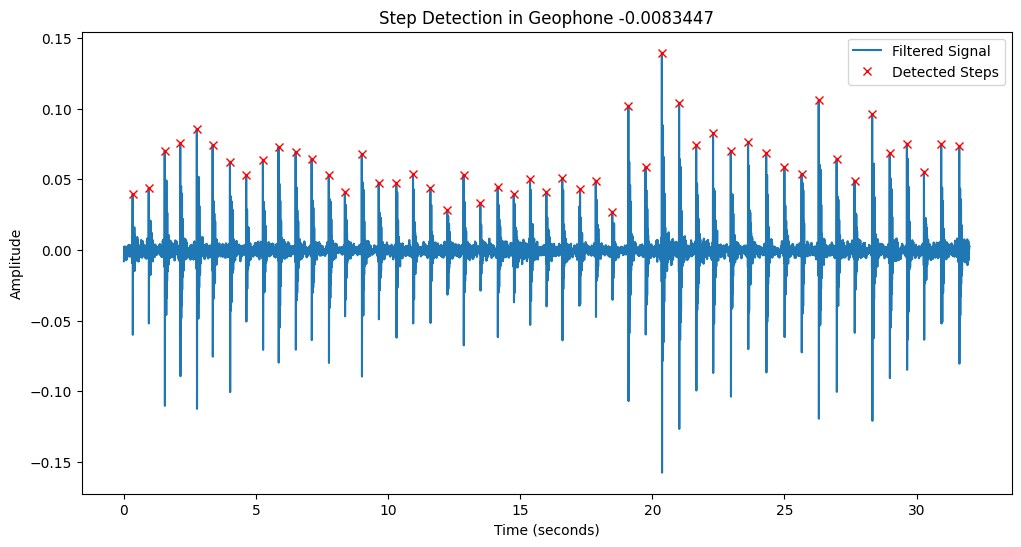

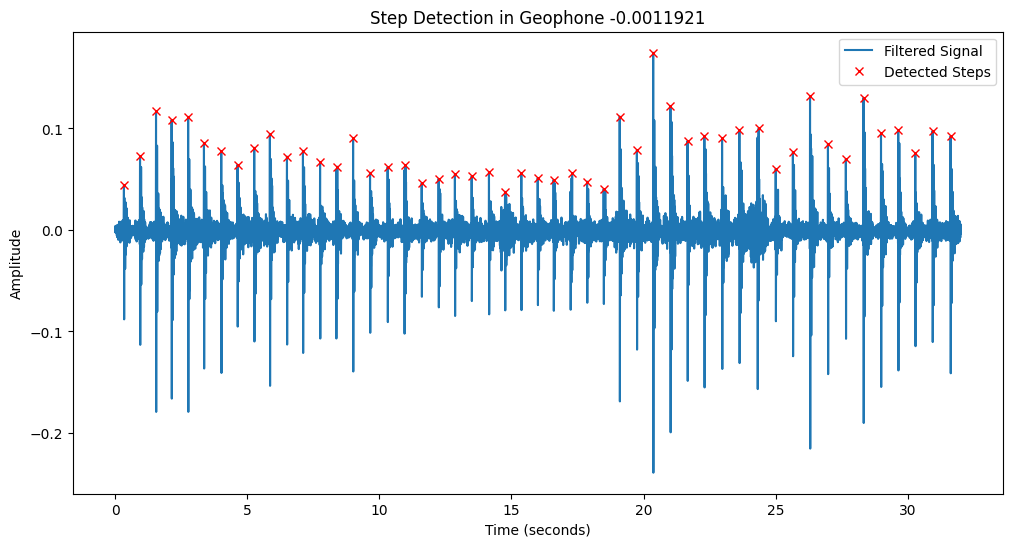

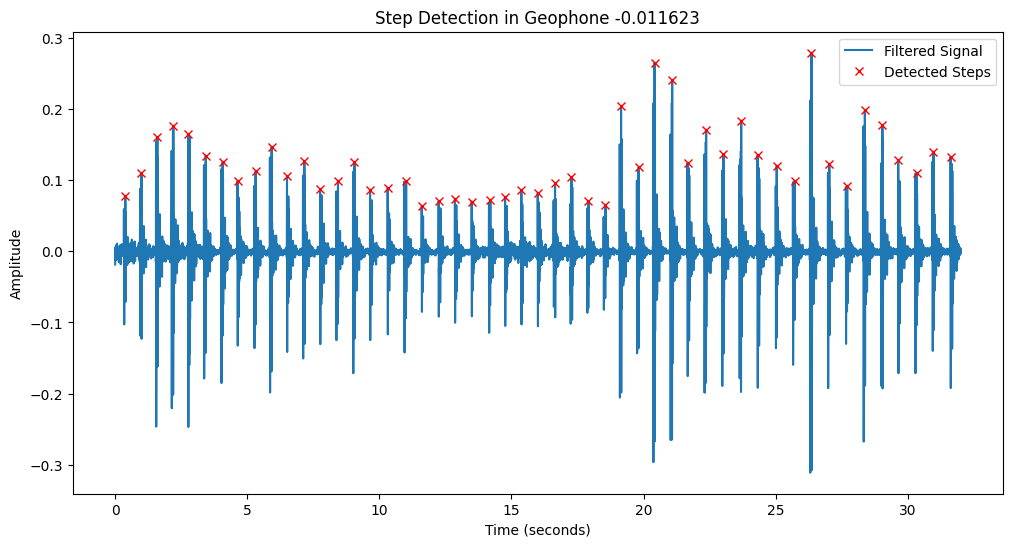

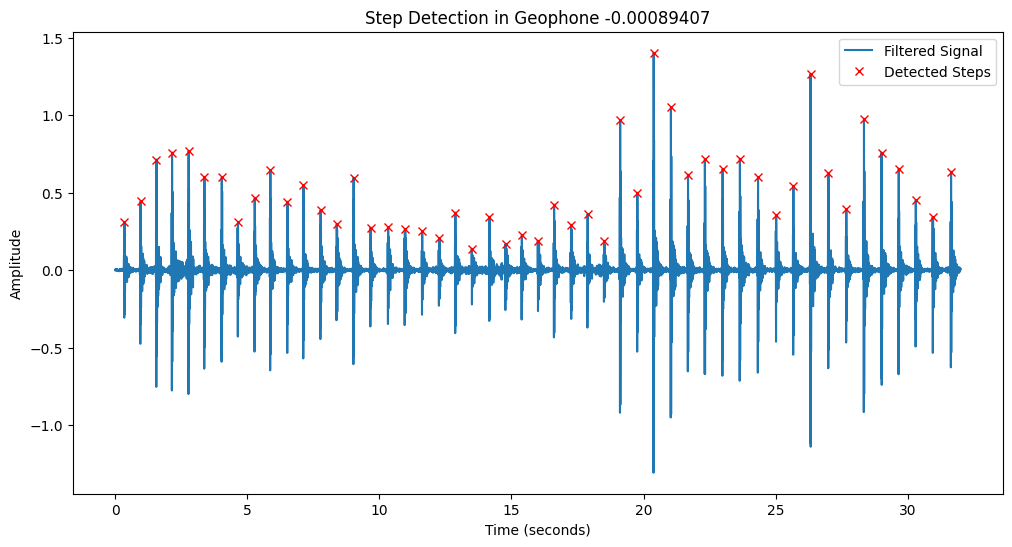

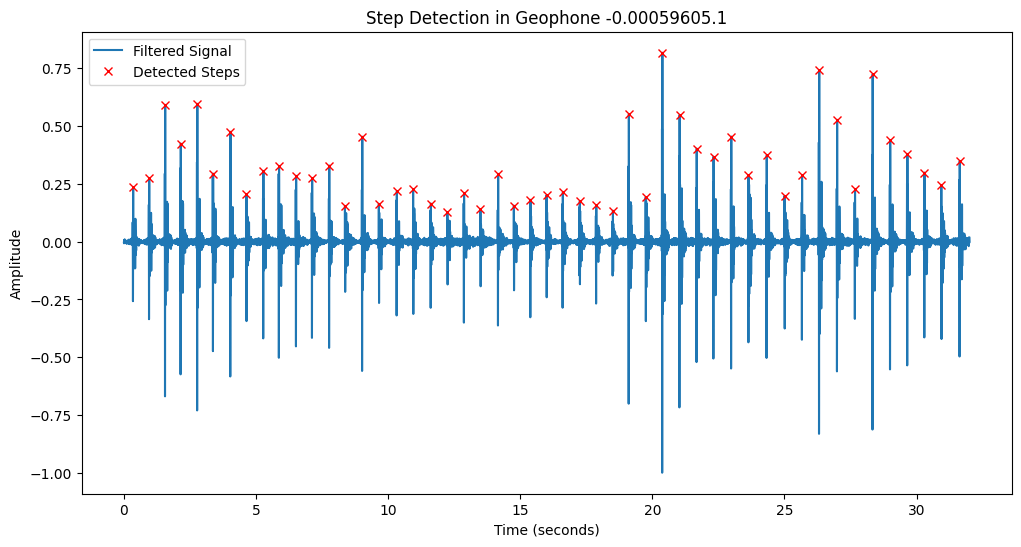

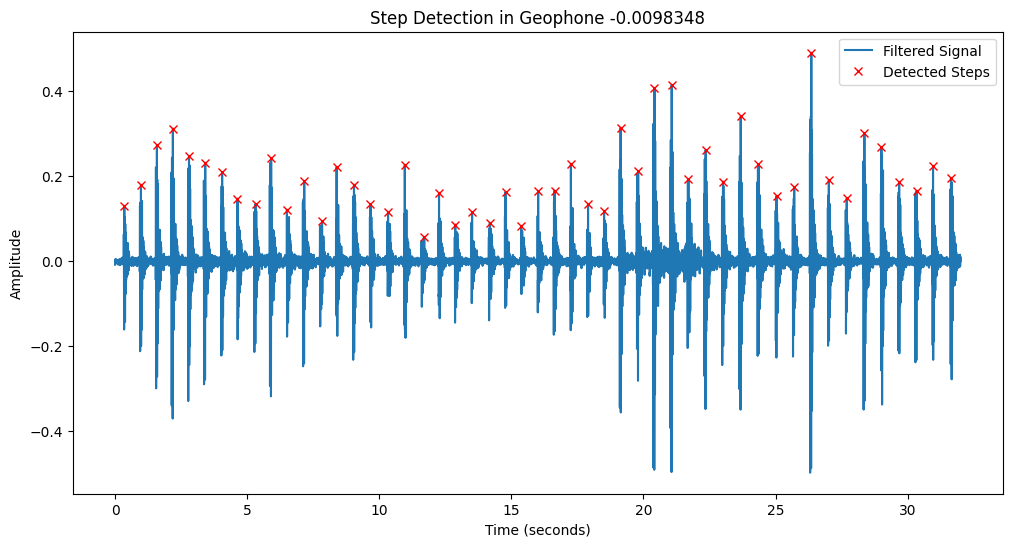

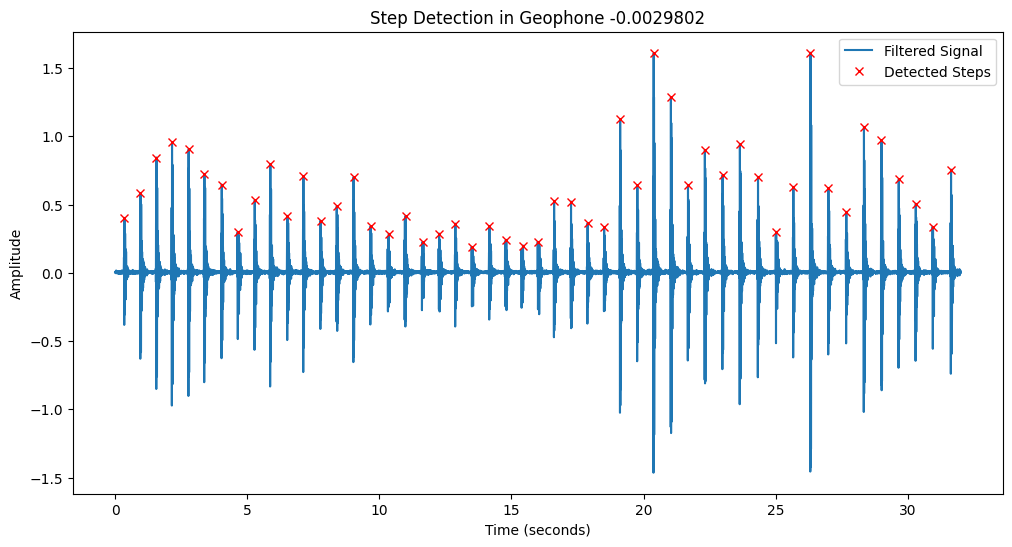

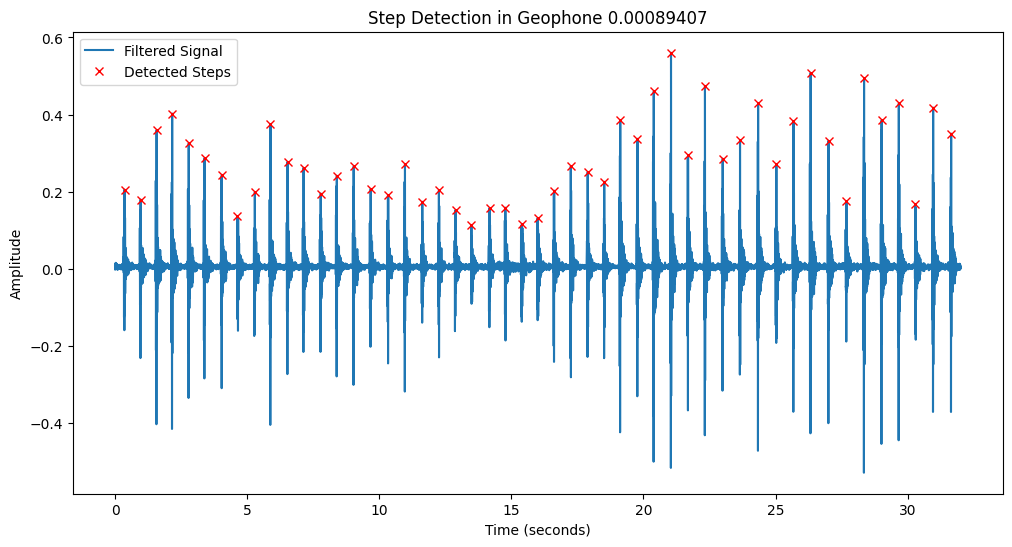

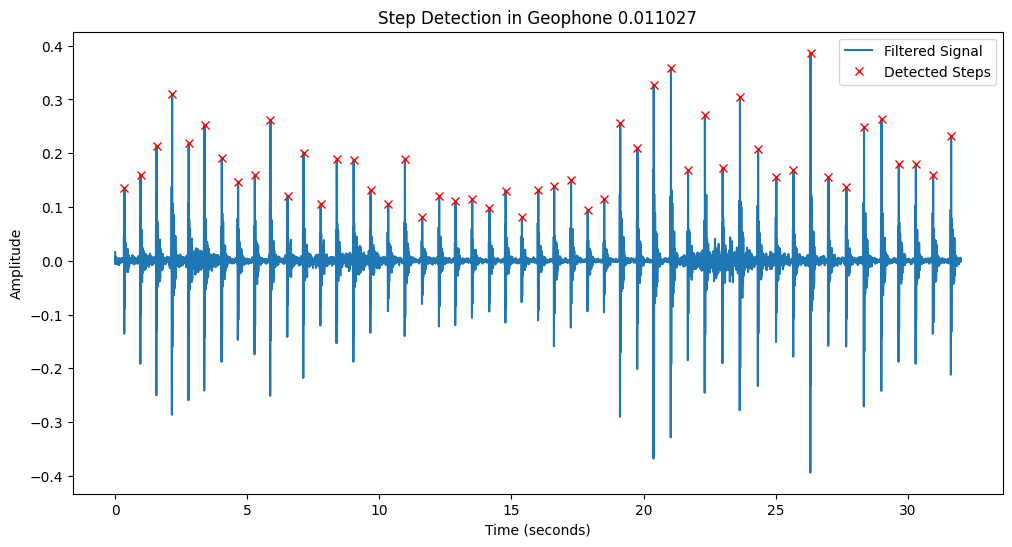

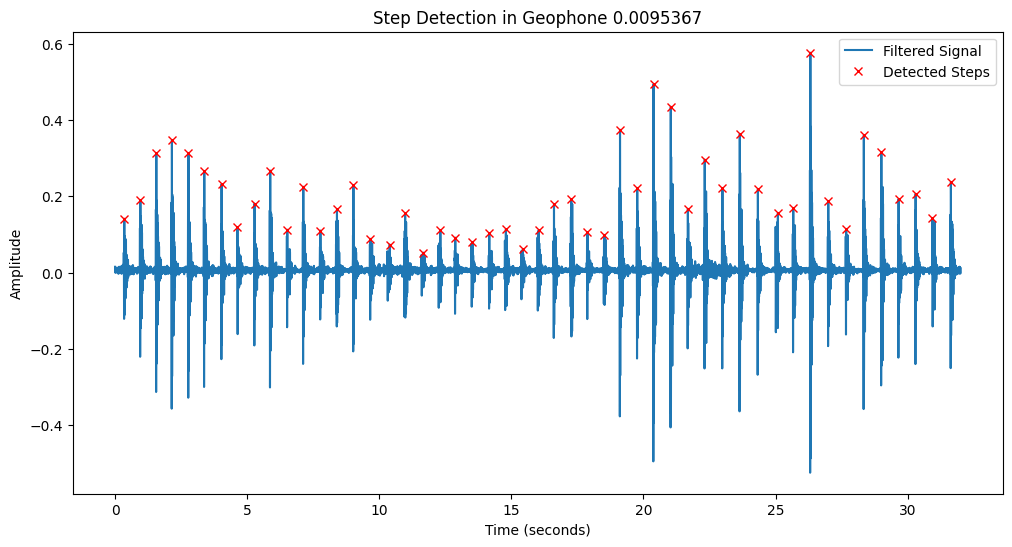

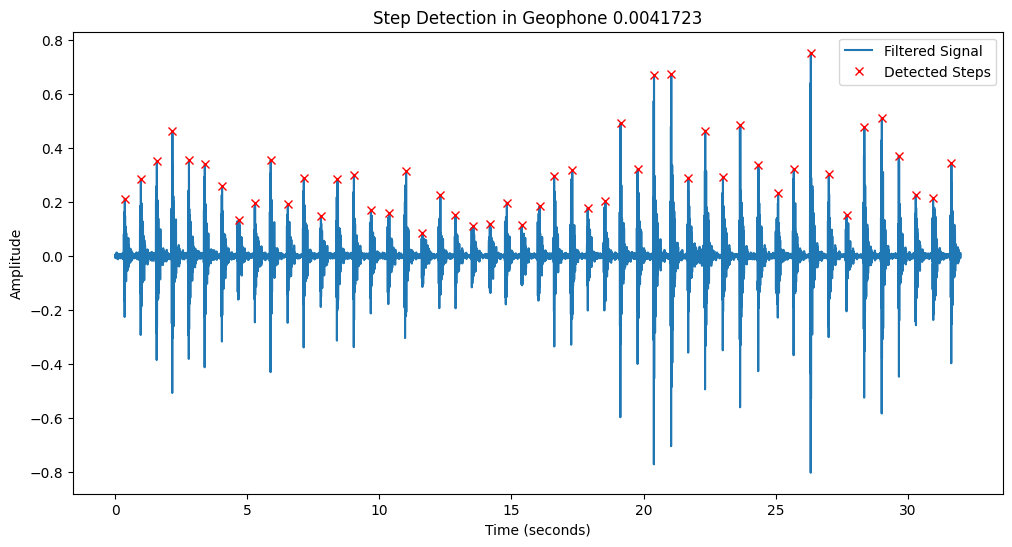

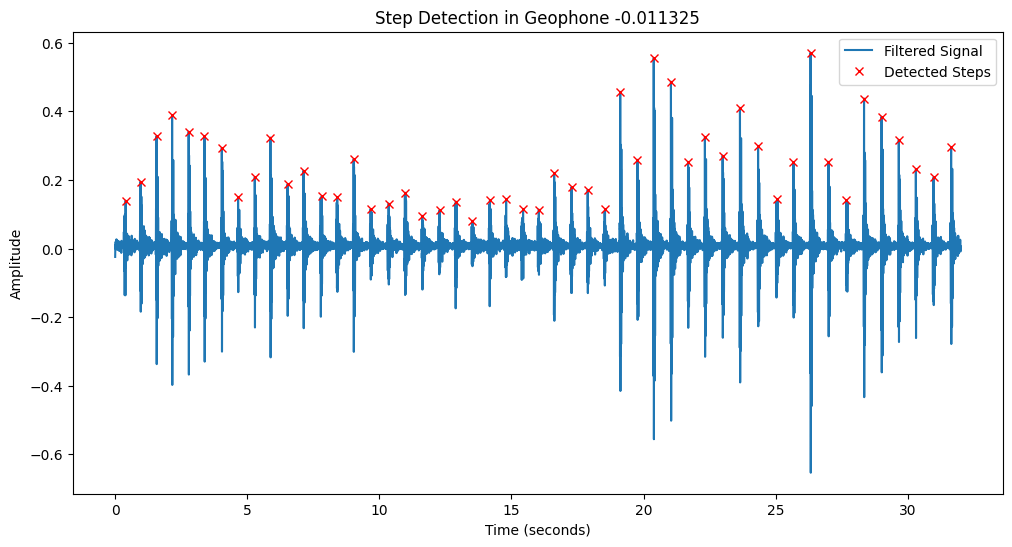

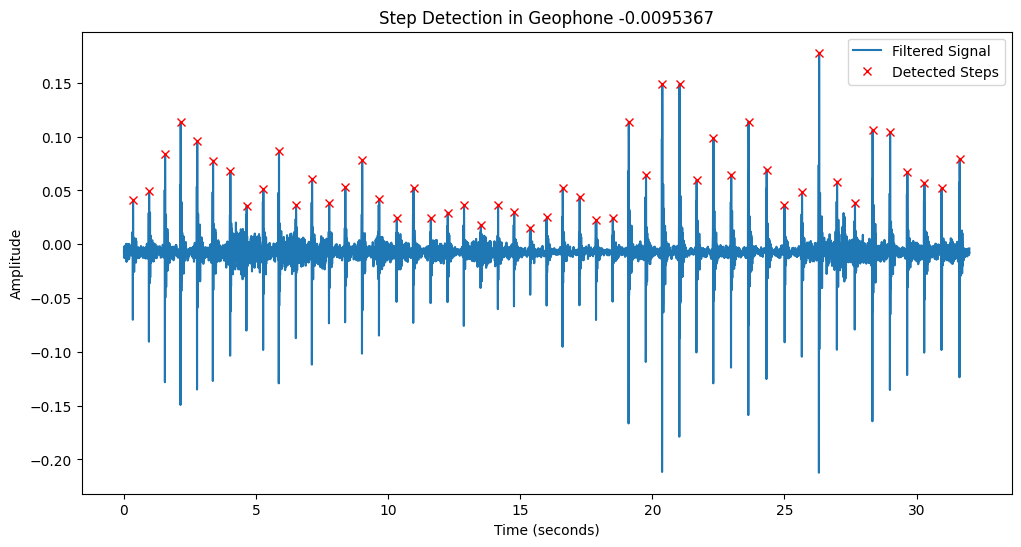

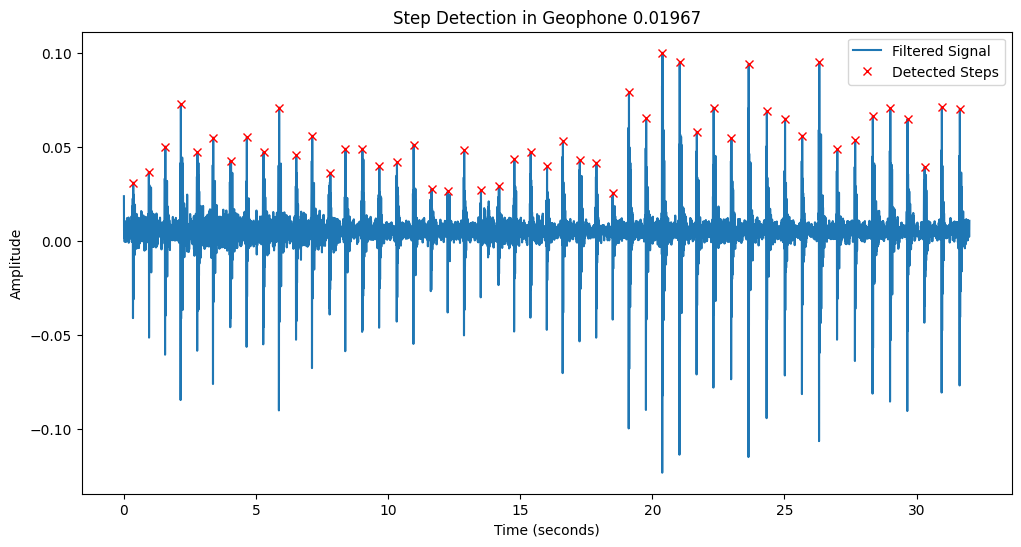

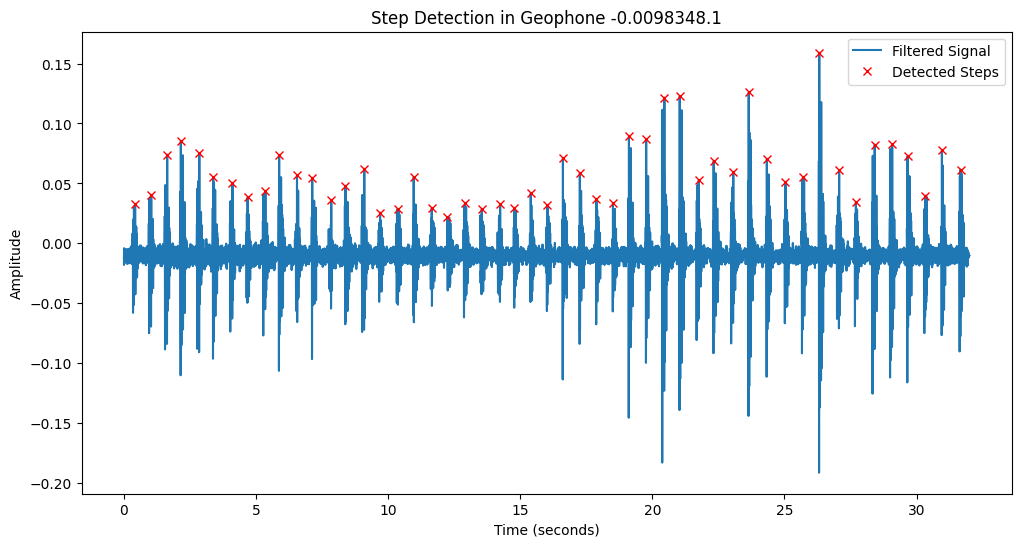

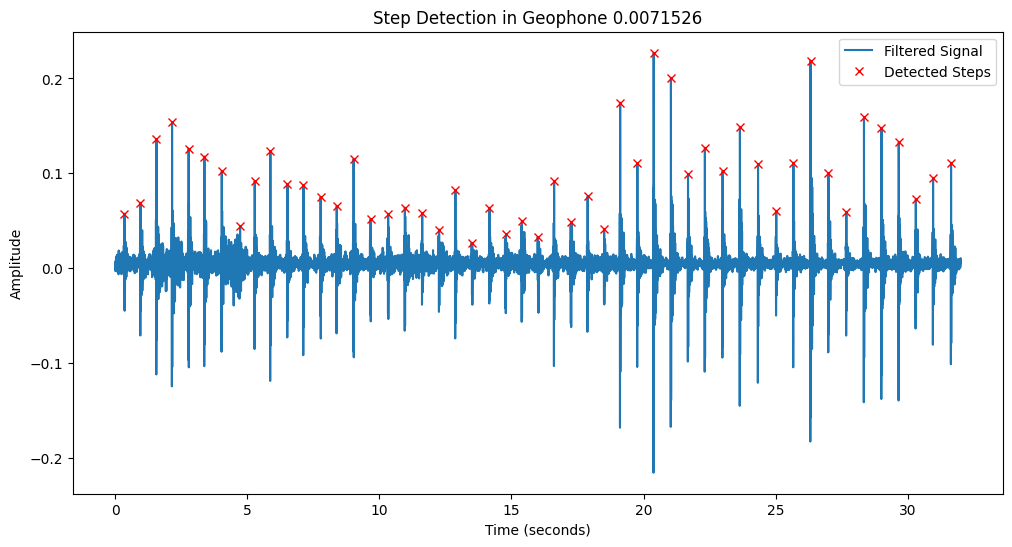

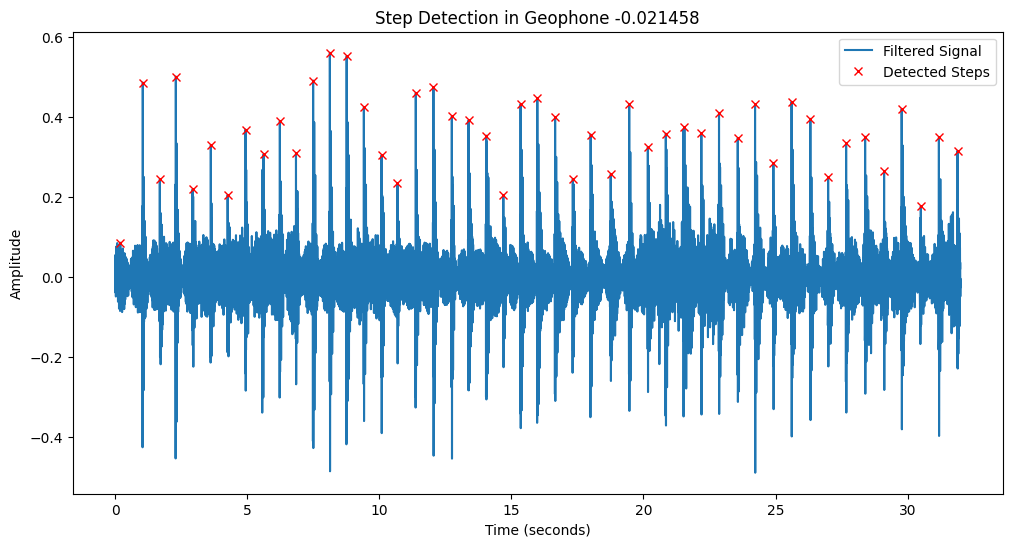

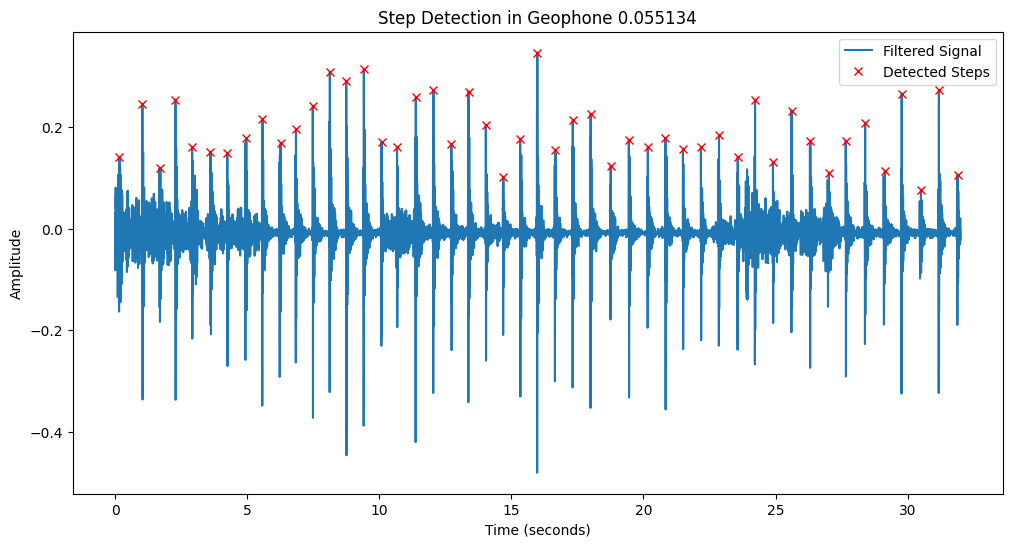

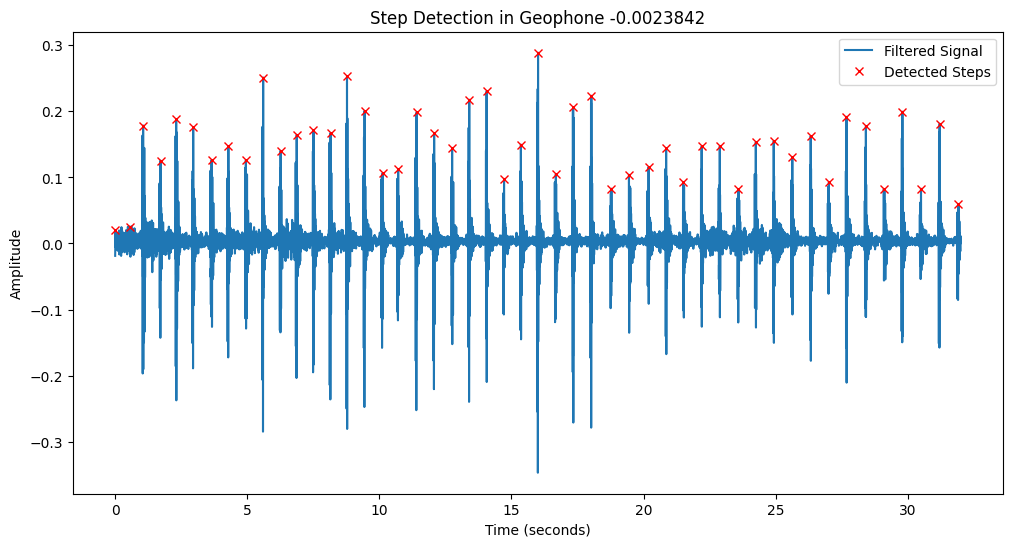

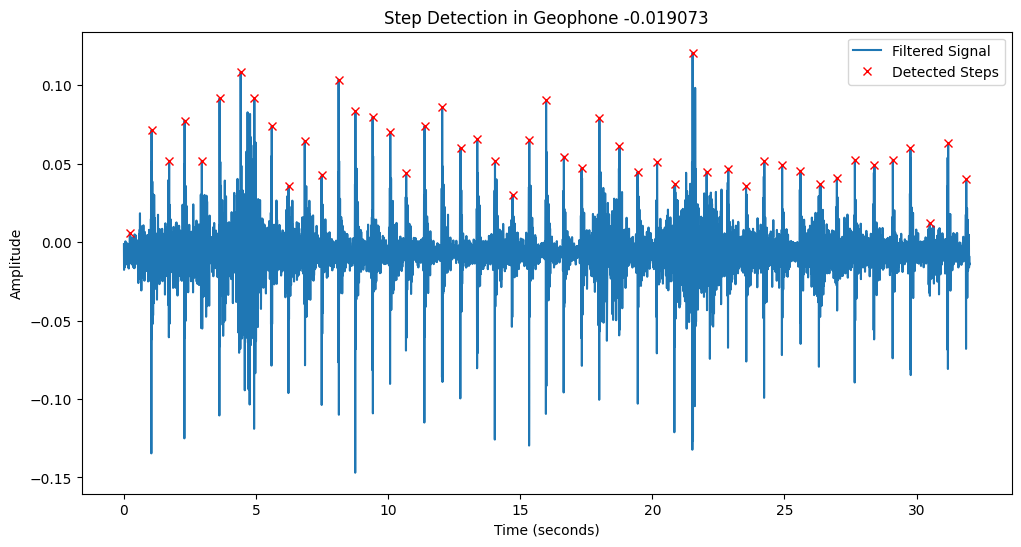

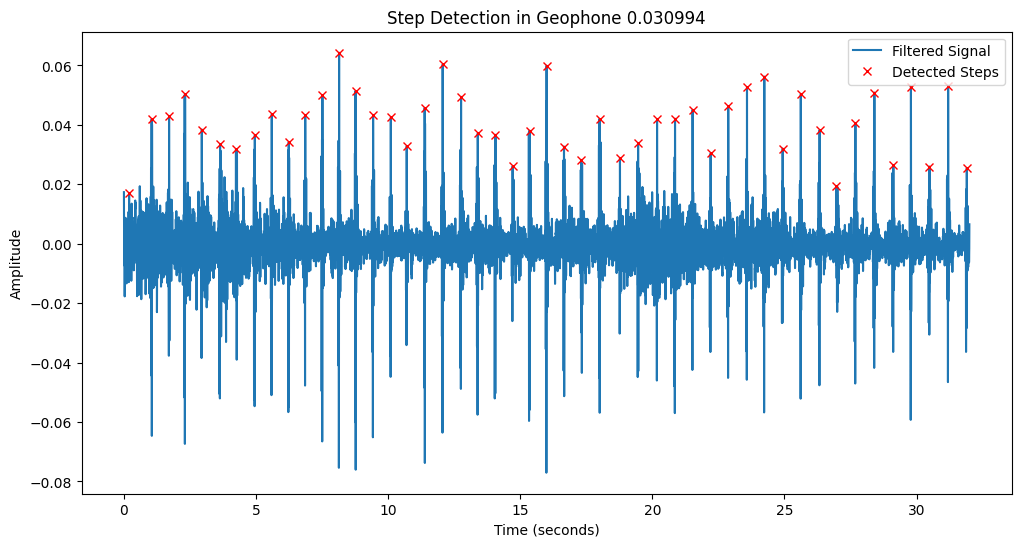

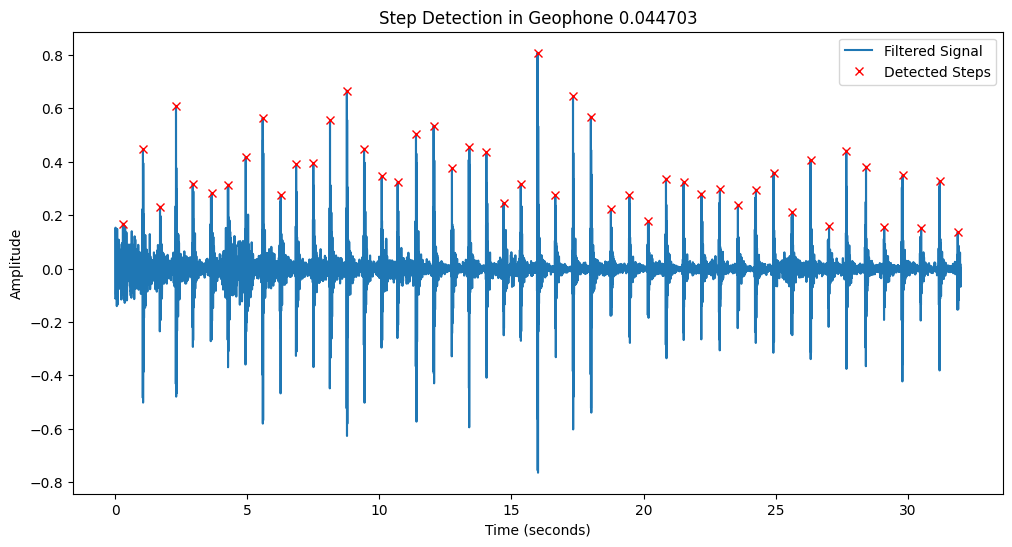

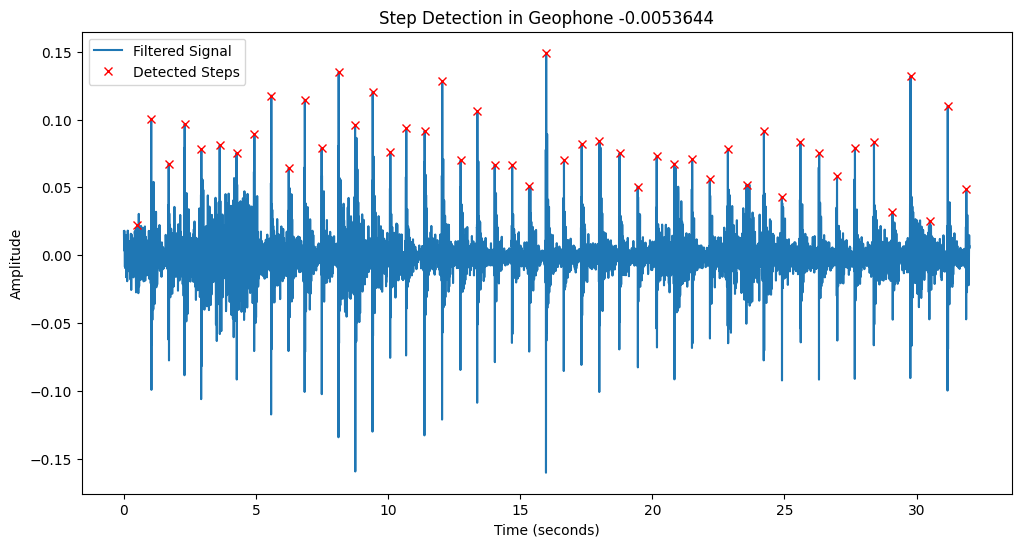

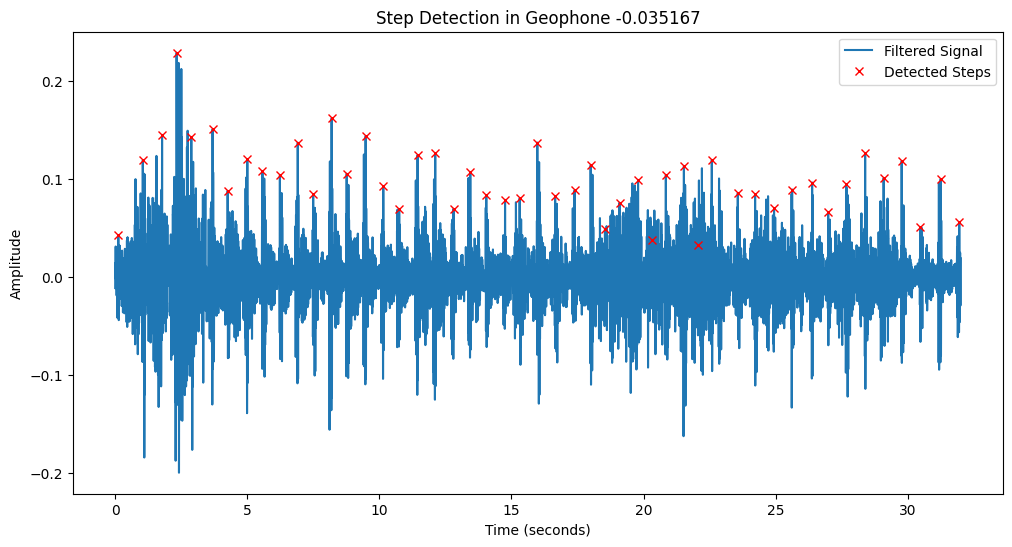

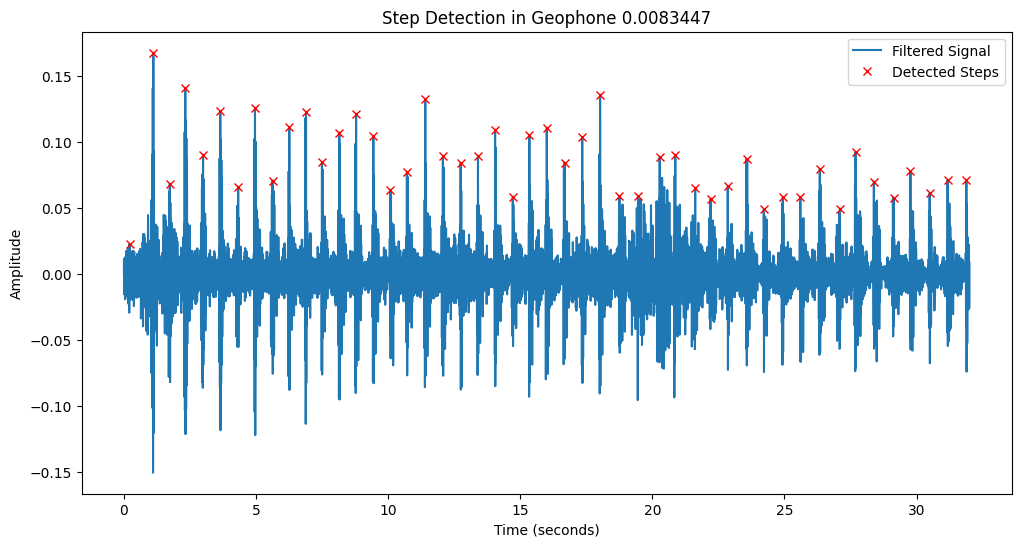

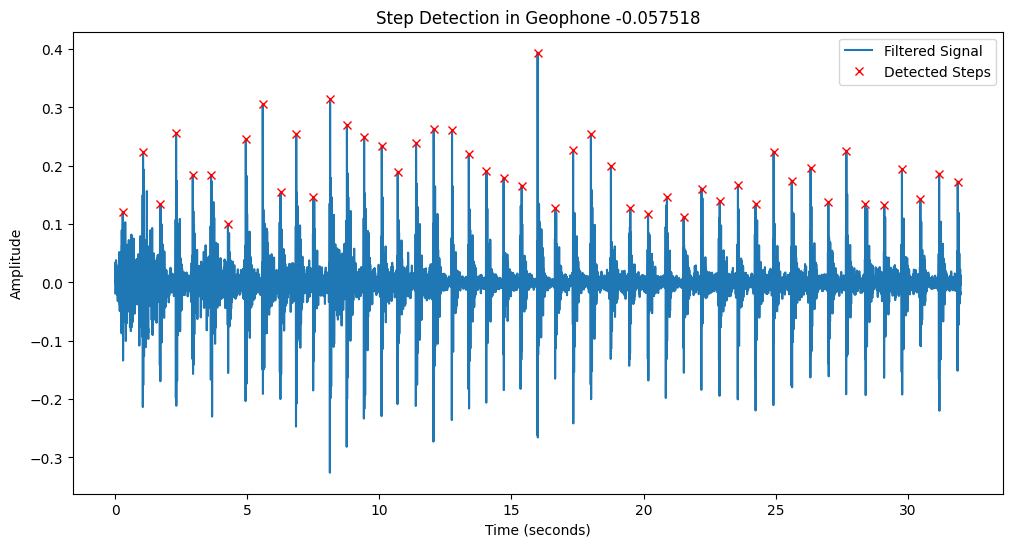

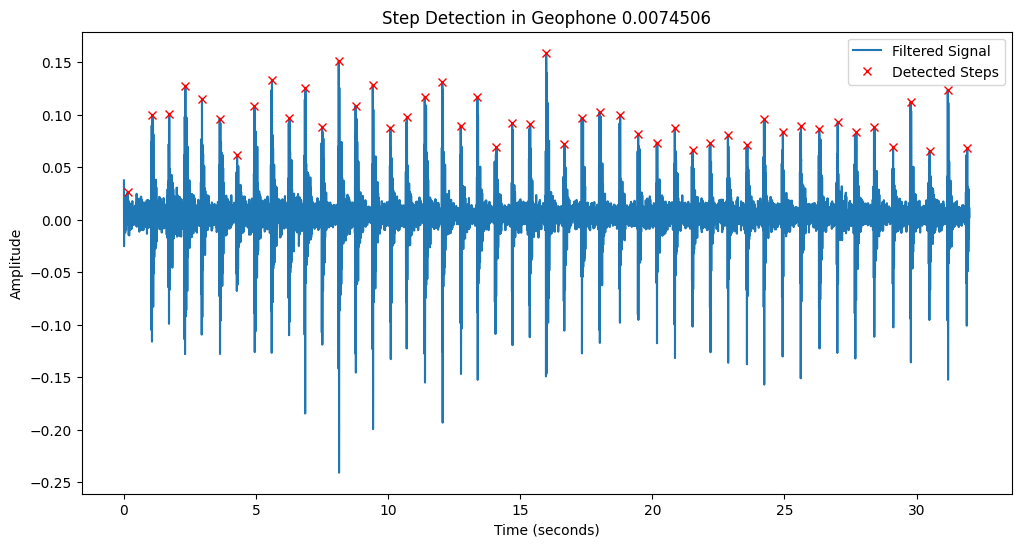

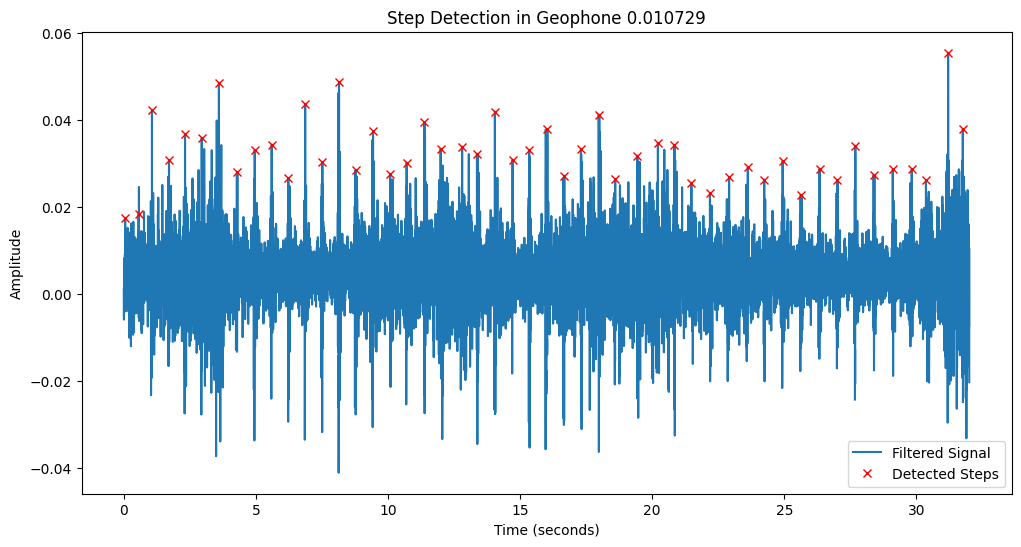

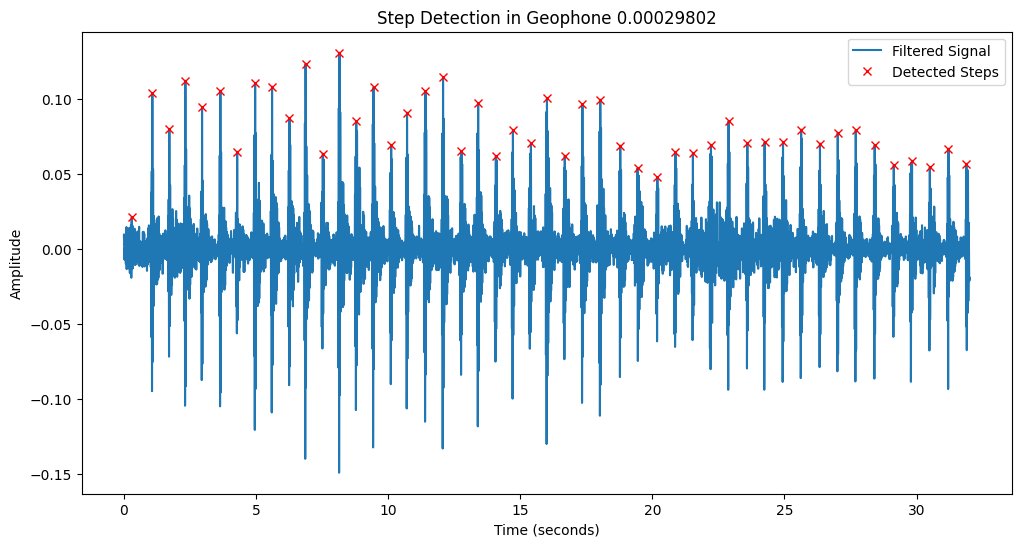

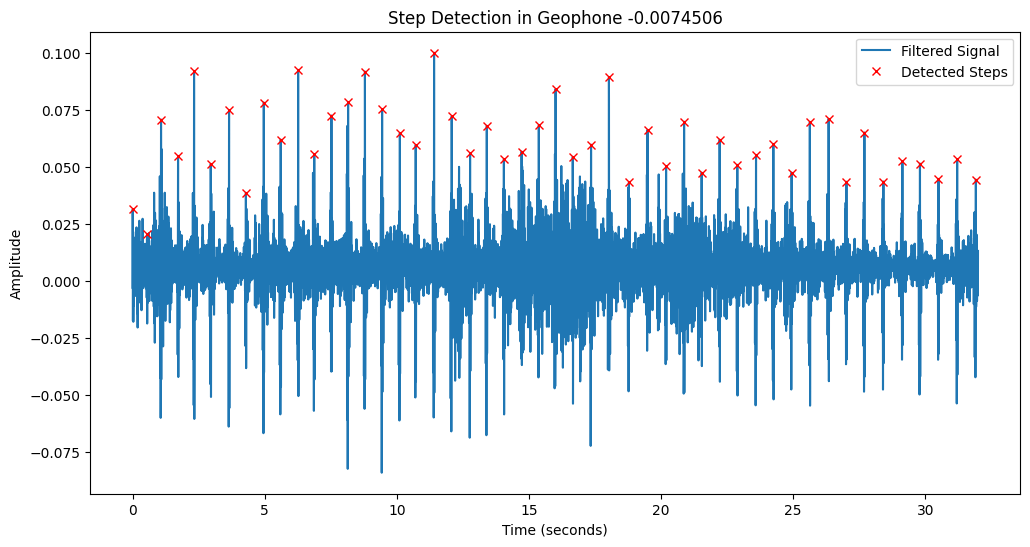

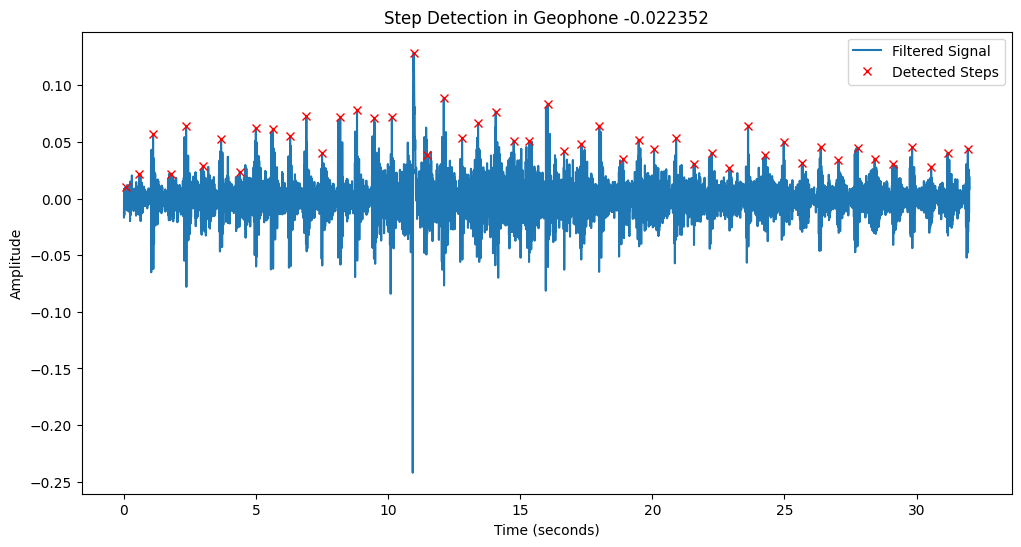

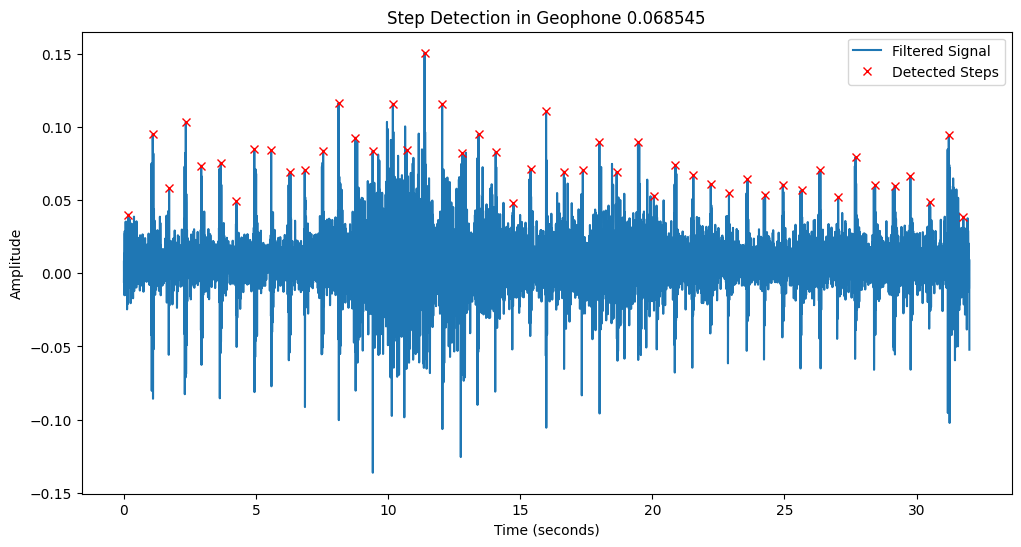

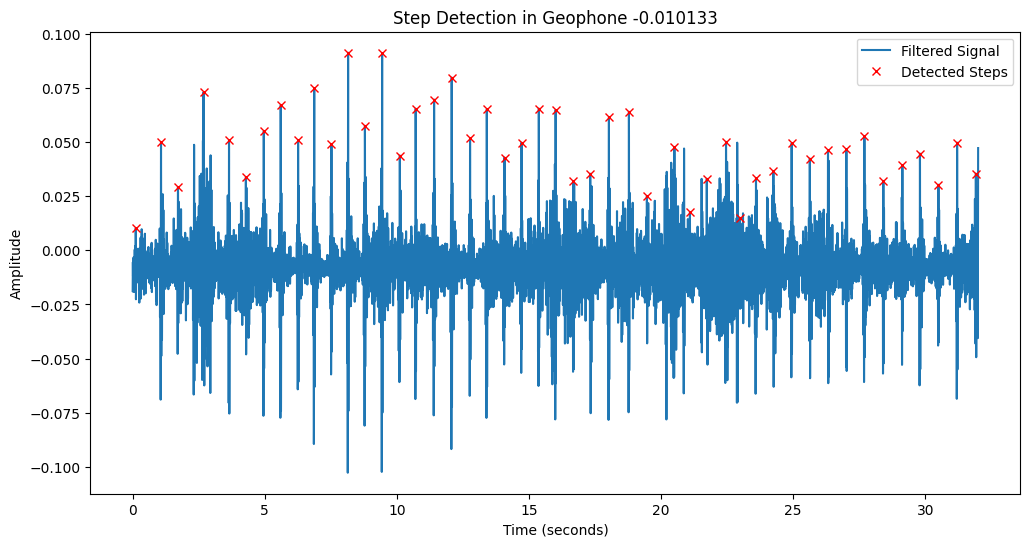

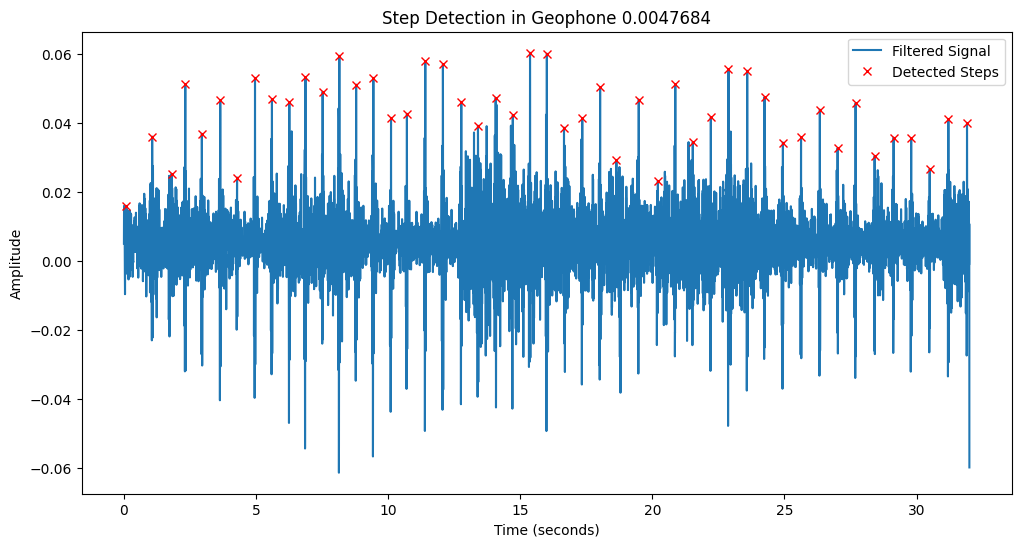

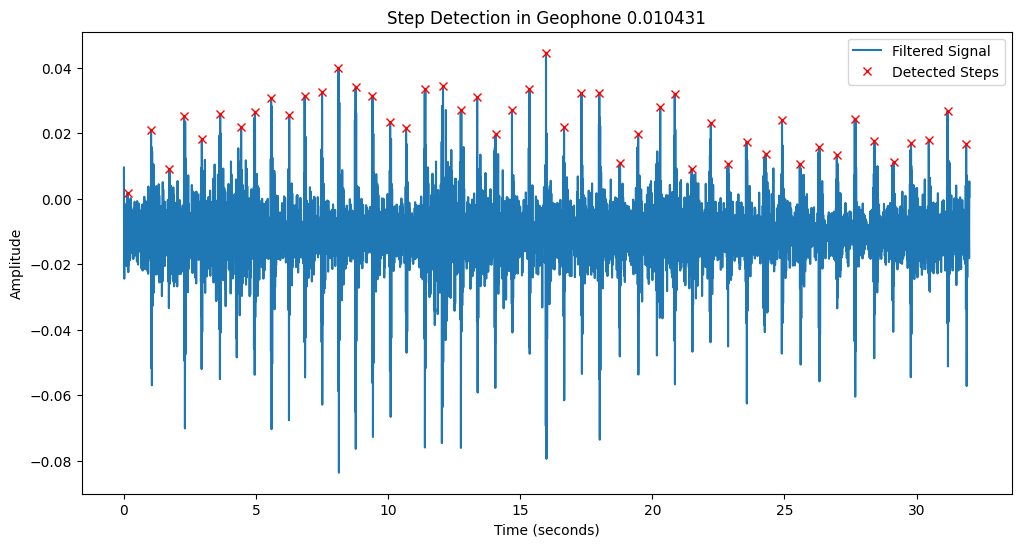

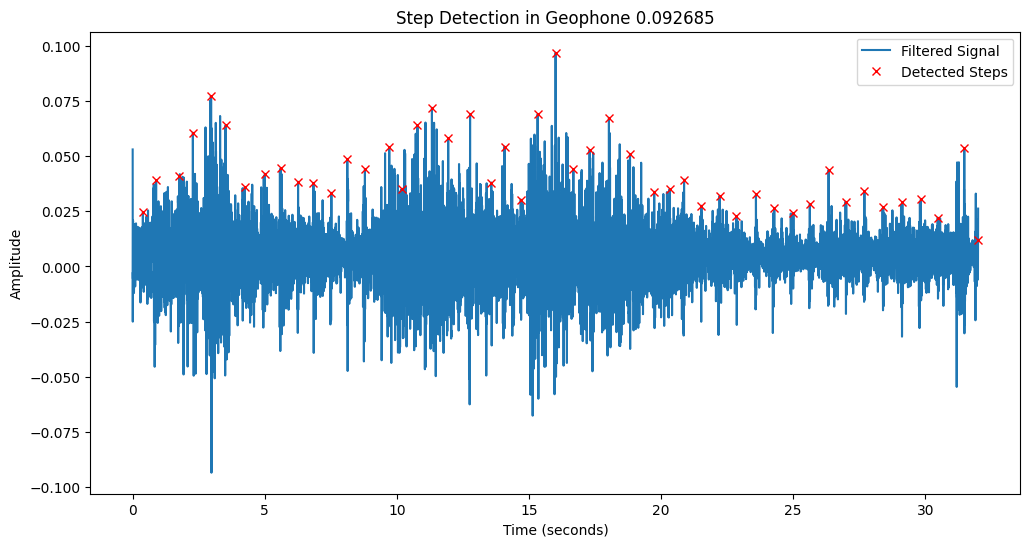

Shape of quiet_data: (27999, 39)
First few rows of quiet_data before processing:
       -0.00059605  -0.0044703  -0.0056624  -0.0083447  -0.0011921  -0.011623  \
32000    -0.004768    0.001192   -0.002682    0.011325   -0.006556   0.000000   
32001    -0.005066    0.005960   -0.005662    0.017285   -0.007153  -0.003576   
32002    -0.005960    0.005364   -0.006259    0.007749   -0.005960  -0.003576   
32003    -0.008047    0.007153   -0.006259   -0.004768    0.000894  -0.001788   
32004    -0.010133    0.009835   -0.006556   -0.011027    0.003278   0.001192   

       -0.00089407  -0.00059605.1  -0.0098348  -0.0029802  ...  0.0074506  \
32000     0.004172       0.002980   -0.001490   -0.002980  ...  -0.000298   
32001     0.004172      -0.013411   -0.001788   -0.002384  ...  -0.006259   
32002    -0.002086      -0.023246    0.000596    0.000596  ...  -0.015497   
32003    -0.009835      -0.003278    0.003576    0.000596  ...  -0.014007   
32004    -0.014901       0.010729    0.000000  

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import csv

# פונקציה לסינון בתדר נמוך
def low_pass_filter(data, cutoff_freq, sampling_rate):
    nyquist = 0.5 * sampling_rate
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(4, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# פרמטרים כלליים
samples_per_second = 1000  # דגימות לשנייה
time_range = 32 * samples_per_second  # 32 שניות עבור WALKING
quiet_start = time_range  # התחלת קטע השקט
cutoff_freq = 100  # תדר חיתוך לסינון בתדר נמוך
step_distance = 500  # מרחק מינימלי בין צעדים
step_height = 0  # גובה מינימלי של פיק

# *** חיתוך צעדים (WALKING) ***
step_windows = []

for col in data.columns[1:]:
    signal = data[col].iloc[:time_range].values
    filtered_signal = low_pass_filter(signal, cutoff_freq, samples_per_second)
    peaks, _ = find_peaks(filtered_signal, height=step_height, distance=step_distance)

    # יצירת חלונות סביב הפיקים
    for peak in peaks:
        start = max(0, peak - 150)
        end = min(len(filtered_signal), peak + 550)
        window = filtered_signal[start:end]
        if len(window) < 700:  # Padding לחלונות קצרים
            window = np.pad(window, (0, 700 - len(window)), 'constant')
        step_windows.append(window)

    # הצגת גרף של האות עם הפיקים
    time = np.arange(len(filtered_signal)) / samples_per_second
    plt.figure(figsize=(12, 6))
    plt.plot(time, filtered_signal, label='Filtered Signal')
    plt.plot([time[p] for p in peaks], [filtered_signal[p] for p in peaks], 'rx', label='Detected Steps')
    plt.title(f"Step Detection in Geophone {col}")
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.show()

# המרת חלונות WALKING למטריצה
walking_windows_matrix = np.array([window for window in step_windows if len(window) == 700])
walking_labels = np.array(["WALKING"] * len(walking_windows_matrix))

# *** חיתוך שקט (QUIET) ***
quiet_data = data.iloc[quiet_start:, 1:]  # כל הסנסורים

# בדיקה של הנתונים החתוכים
print(f"Shape of quiet_data: {quiet_data.shape}")
print(f"First few rows of quiet_data before processing:\n{quiet_data.head()}")

# טיפול ב-NaN אם קיים
if quiet_data.isna().any().any():
    print("Found NaN values in quiet_data, replacing with 0.")
    quiet_data = quiet_data.fillna(0)

quiet_windows = []
for col in quiet_data.columns:
    signal = quiet_data[col].values
    filtered_signal = low_pass_filter(signal, cutoff_freq, samples_per_second)

    # חלוקת קטע השקט לחלונות בגודל קבוע
    for i in range(0, len(filtered_signal), 700):
        window = filtered_signal[i:i + 700]
        if len(window) < 700:  # Padding לחלונות קצרים
            window = np.pad(window, (0, 700 - len(window)), 'constant')
        quiet_windows.append(window)

# המרת חלונות QUIET למטריצה
quiet_windows_matrix = np.array(quiet_windows)
quiet_labels = np.array(["QUIET"] * len(quiet_windows_matrix))

# *** שילוב כל החלונות ***
all_windows = np.vstack([walking_windows_matrix, quiet_windows_matrix])
all_labels = np.concatenate([walking_labels, quiet_labels])

# שמירת כל החלונות לקובץ CSV
output_file = "walking_and_quiet_windows.csv"
with open(output_file, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Window Index", "Sensor Data (Flattened)", "Label"])  # כותרת עמודות
    for i, (window, label) in enumerate(zip(all_windows, all_labels)):
        flattened_window = window.flatten()  # שטיחה של הנתונים
        writer.writerow([i, list(flattened_window), label])

print(f"Windows with labels saved to '{output_file}'")

# הדפסת מספר חלונות לכל קטגוריה
print(f"Number of WALKING Windows: {len(walking_windows_matrix)}")
print(f"Number of QUIET Windows: {len(quiet_windows_matrix)}")
print(f"Total Windows: {len(all_windows)}")


In [31]:
# חישוב FFT Mean ו-FFT Max עבור כל חלון ב-WALKING
walking_features = [calculate_fft_features(window) for window in walking_windows_matrix]
walking_fft_mean = [f[0] for f in walking_features]
walking_fft_max = [f[1] for f in walking_features]

# חישוב FFT Mean ו-FFT Max עבור כל חלון ב-QUIET
quiet_features = [calculate_fft_features(window) for window in quiet_windows_matrix]
quiet_fft_mean = [f[0] for f in quiet_features]
quiet_fft_max = [f[1] for f in quiet_features]

# סטטיסטיקות
print("WALKING Statistics:")
print(f"Mean of FFT Mean: {np.mean(walking_fft_mean):.2f}, Std: {np.std(walking_fft_mean):.2f}")
print(f"Mean of FFT Max: {np.mean(walking_fft_max):.2f}, Std: {np.std(walking_fft_max):.2f}")

print("\nQUIET Statistics:")
print(f"Mean of FFT Mean: {np.mean(quiet_fft_mean):.2f}, Std: {np.std(quiet_fft_mean):.2f}")
print(f"Mean of FFT Max: {np.mean(quiet_fft_max):.2f}, Std: {np.std(quiet_fft_max):.2f}")


WALKING Statistics:
Mean of FFT Mean: 0.28, Std: 0.24
Mean of FFT Max: 5.49, Std: 4.08

QUIET Statistics:
Mean of FFT Mean: 0.07, Std: 0.08
Mean of FFT Max: 3.37, Std: 2.40


In [13]:
import numpy as np

def extract_features(window):
    """
    Extracts features from a single window.
    """
    # סטטיסטיקות בסיסיות
    mean_val = np.mean(window)
    std_val = np.std(window)
    max_val = np.max(window)
    min_val = np.min(window)

    # אנרגיה כוללת
    energy = np.sum(window**2)

    # Zero-Crossing Rate
    zero_crossings = np.sum(np.diff(np.sign(window)) != 0)

    # FFT - ספקטרום התדרים
    fft_vals = np.abs(np.fft.fft(window))[:len(window)//2]  # רק מחצית מהספקטרום
    fft_mean = np.mean(fft_vals)
    fft_max = np.max(fft_vals)

    return [mean_val, std_val, max_val, min_val, energy, zero_crossings, fft_mean, fft_max]

# חילוץ תכונות מכל חלון
features = []
for window in all_windows:
    features.append(extract_features(window))

# הפיכת הרשימה למערך NumPy
features_matrix = np.array(features)

# בדיקה ראשונית
print("Feature Matrix Shape:", features_matrix.shape)


Feature Matrix Shape: (3474, 8)


Column -0.0301 has no significant high amplitudes after filtering.
Column -0.00059605 has no significant high amplitudes after filtering.
Column -0.0044703 has no significant high amplitudes after filtering.
Column -0.0056624 has no significant high amplitudes after filtering.
Column -0.0083447 has no significant high amplitudes after filtering.
Column -0.0011921 has no significant high amplitudes after filtering.
Column -0.011623 has no significant high amplitudes after filtering.


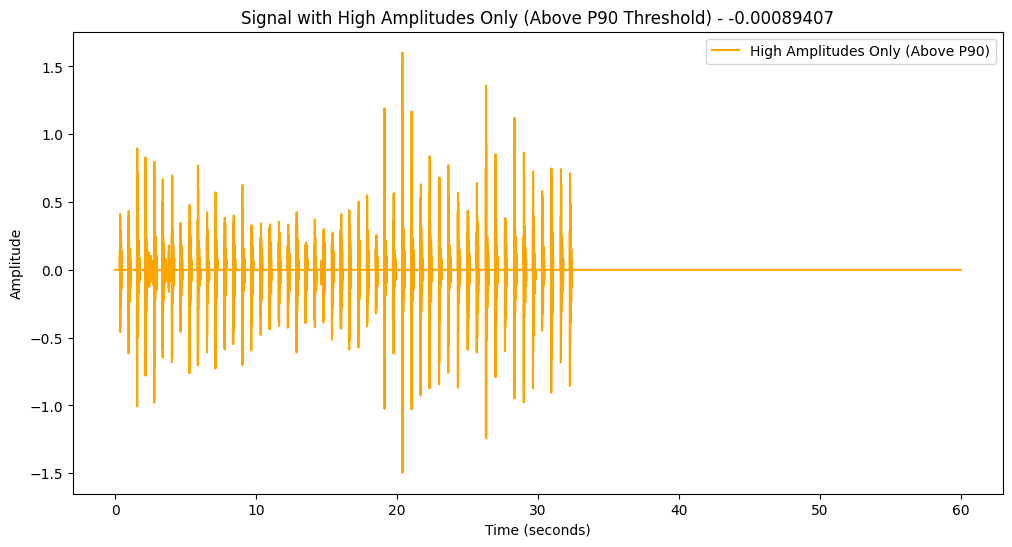

Column -0.00059605.1 has no significant high amplitudes after filtering.
Column -0.0098348 has no significant high amplitudes after filtering.


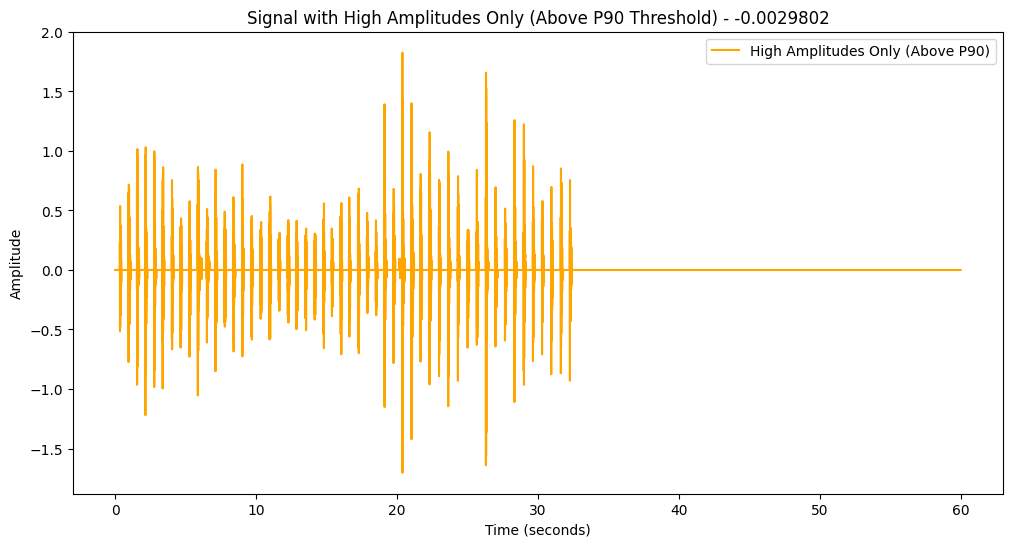

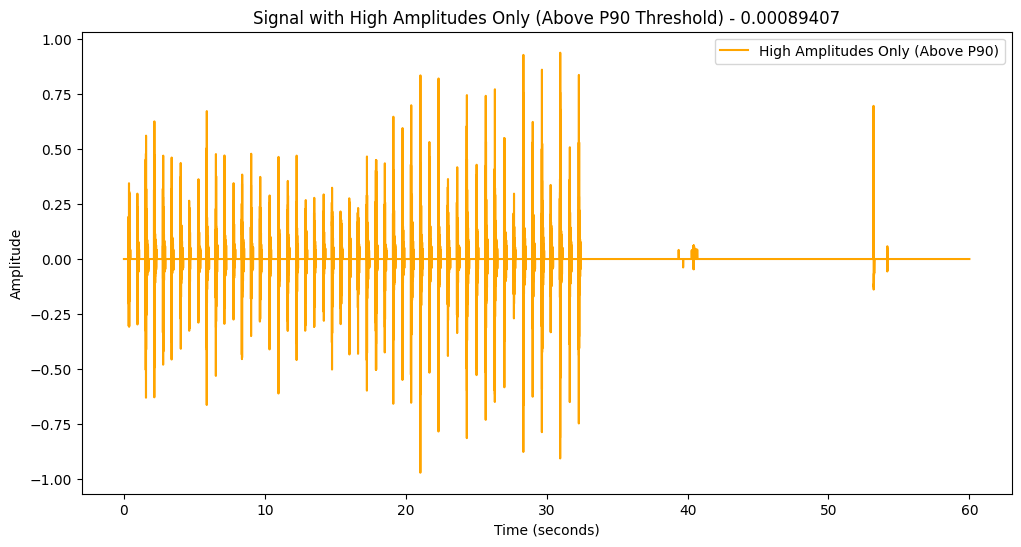

Column 0.011027 has no significant high amplitudes after filtering.
Column 0.0095367 has no significant high amplitudes after filtering.


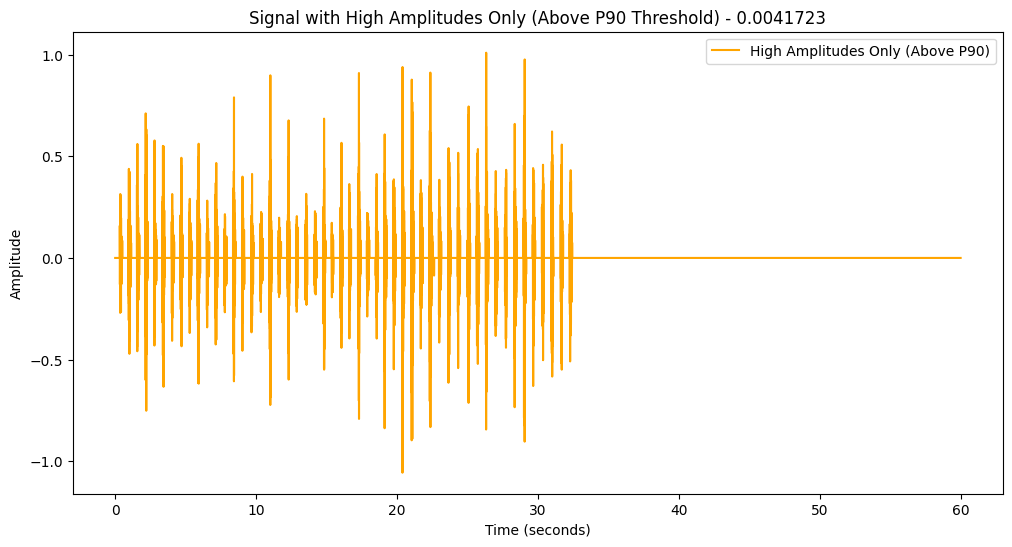

Column -0.011325 has no significant high amplitudes after filtering.
Column -0.0095367 has no significant high amplitudes after filtering.
Column 0.01967 has no significant high amplitudes after filtering.
Column -0.0098348.1 has no significant high amplitudes after filtering.
Column 0.0071526 has no significant high amplitudes after filtering.
Column -0.021458 has no significant high amplitudes after filtering.


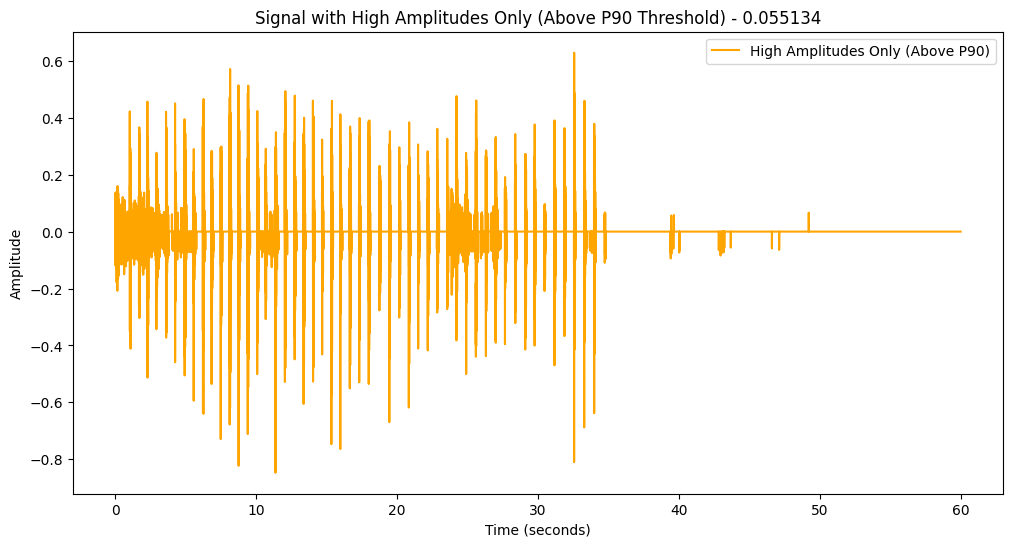

Column -0.0023842 has no significant high amplitudes after filtering.
Column -0.019073 has no significant high amplitudes after filtering.
Column 0.030994 has no significant high amplitudes after filtering.
Column 0.044703 has no significant high amplitudes after filtering.
Column -0.0053644 has no significant high amplitudes after filtering.
Column -0.035167 has no significant high amplitudes after filtering.
Column 0.0083447 has no significant high amplitudes after filtering.
Column -0.057518 has no significant high amplitudes after filtering.
Column 0.0074506 has no significant high amplitudes after filtering.
Column 0.010729 has no significant high amplitudes after filtering.
Column 0.00029802 has no significant high amplitudes after filtering.
Column -0.0074506 has no significant high amplitudes after filtering.
Column -0.022352 has no significant high amplitudes after filtering.
Column 0.068545 has no significant high amplitudes after filtering.
Column -0.010133 has no significan

In [38]:
# סינון אמפליטודות נמוכות והצגת גרפים עבור כל עמודה
for col in data.columns:
    signal = data[col]
    time = np.linspace(0, len(signal) / 1000, len(signal))  # יצירת ציר זמן
    
    # חישוב P90 באופן דינמי
    p90_amplitude = np.percentile(np.abs(signal), 92)
    
    # סינון האמפליטודות הנמוכות
    filtered_amplitudes = np.where(np.abs(signal) >= p90_amplitude, signal, 0)
    
    # בדיקה האם יש מספיק נתונים אחרי הסינון
    if np.count_nonzero(filtered_amplitudes) > 0:
        # הצגת האות עם אמפליטודות גבוהות בלבד
        plt.figure(figsize=(12, 6))
        plt.plot(time, filtered_amplitudes, label='High Amplitudes Only (Above P90)', color='orange')
        plt.title(f'Signal with High Amplitudes Only (Above P90 Threshold) - {col}')
        plt.xlabel('Time (seconds)')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.show()
    else:
        print(f'Column {col} has no significant high amplitudes after filtering.')

print('Filtering and visualization completed for all columns.')